In [1]:
import pandas as pd
import numpy as np
import joblib
import json
import time

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [6]:
df = pd.read_parquet("../data/processed/02_cleaned.parquet")

In [7]:
import pandas as pd

df = pd.read_parquet("../data/processed/02_cleaned.parquet")

df.head()

,timestamp,temperature,humidity,co2,yield_kg
0,2025-01-01 00:00:00,25.993428,68.317314,1080.786751,13.825416
1,2025-01-01 01:00:00,24.723471,85.487572,1118.317068,13.813510
2,2025-01-01 02:00:00,26.295377,72.872410,1156.002137,14.305479
3,2025-01-01 03:00:00,28.046060,82.130704,935.198063,13.021004
4,2025-01-01 04:00:00,24.531693,82.173540,950.233181,13.681953


In [8]:
print(df.columns.tolist())

['timestamp', 'temperature', 'humidity', 'co2', 'yield_kg']


In [9]:
import pandas as pd
import numpy as np
import joblib
import json
import time

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

In [10]:
df = pd.read_parquet("../data/processed/02_cleaned.parquet")

df.head()

,timestamp,temperature,humidity,co2,yield_kg
0,2025-01-01 00:00:00,25.993428,68.317314,1080.786751,13.825416
1,2025-01-01 01:00:00,24.723471,85.487572,1118.317068,13.813510
2,2025-01-01 02:00:00,26.295377,72.872410,1156.002137,14.305479
3,2025-01-01 03:00:00,28.046060,82.130704,935.198063,13.021004
4,2025-01-01 04:00:00,24.531693,82.173540,950.233181,13.681953


In [11]:
X = df[['temperature', 'humidity', 'co2']]
y = df['yield_kg']

print(X.shape)
print(y.shape)

(120, 3)
(120,)


In [12]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Train Size:", len(X_train))
print("Test Size :", len(X_test))

Train Size: 96
Test Size : 24


In [13]:
linear_model = LinearRegression()

start = time.time()

linear_model.fit(X_train, y_train)

linear_time = time.time() - start

linear_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_r2 = r2_score(y_test, linear_pred)

print("Linear Regression Results")
print("MAE :", round(linear_mae,3))
print("RMSE:", round(linear_rmse,3))
print("R²  :", round(linear_r2,3))

Linear Regression Results
MAE : 0.978
RMSE: 1.137
R²  : 0.01


In [14]:
rf_default = RandomForestRegressor(
    random_state=42
)

start = time.time()

rf_default.fit(X_train, y_train)

rf_time = time.time() - start

rf_pred = rf_default.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Default RF Results")
print("MAE :", round(rf_mae,3))
print("RMSE:", round(rf_rmse,3))
print("R²  :", round(rf_r2,3))

Default RF Results
MAE : 0.962
RMSE: 1.166
R²  : -0.041


In [15]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 27 candidates, totalling 135 fits
[CV] END ...max_depth=3, min_samples_leaf=1, n_estimators=50; total time=   0.1s
[CV] END ...max_depth=3, min_samples_leaf=1, n_estimators=50; total time=   0.1s
[CV] END ...max_depth=3, min_samples_leaf=1, n_estimators=50; total time=   0.1s
[CV] END ...max_depth=3, min_samples_leaf=1, n_estimators=50; total time=   0.1s
[CV] END ...max_depth=3, min_samples_leaf=1, n_estimators=50; total time=   0.1s
[CV] END ..max_depth=3, min_samples_leaf=1, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=3, min_samples_leaf=1, n_estimators=100; total time=   0.1s
[CV] END ..max_depth=3, min_samples_leaf=1, n_estimators=100; total time=   0.2s
[CV] END ..max_depth=3, min_samples_leaf=1, n_estimators=100; total time=   0.1s
[CV] END ...max_depth=3, min_samples_leaf=2, n_estimators=50; total time=   0.0s
[CV] END ..max_depth=3, min_samples_leaf=1, n_estimators=100; total time=   0.1s
[CV] END ...max_depth=3, min_samples_leaf=2, n_

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",TimeSeriesSpl...est_size=None)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sp

In [16]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest CV MAE:")
print(abs(grid_search.best_score_))

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'n_estimators': 100}

Best CV MAE:
0.8528714852300784


In [17]:
best_rf = grid_search.best_estimator_

tuned_pred = best_rf.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_r2 = r2_score(y_test, tuned_pred)

print("Tuned RF Results")
print("MAE :", round(tuned_mae,3))
print("RMSE:", round(tuned_rmse,3))
print("R²  :", round(tuned_r2,3))

Tuned RF Results
MAE : 0.966
RMSE: 1.165
R²  : -0.039


In [18]:
with open("../models/rf_best_params.json", "w") as f:
    json.dump(grid_search.best_params_, f, indent=4)

print("Best parameters saved.")

Best parameters saved.


In [19]:
joblib.dump(
    best_rf,
    "../models/champion.joblib"
)

print("Champion model saved.")

Champion model saved.


In [20]:
cv_results = pd.DataFrame(
    grid_search.cv_results_
)

cv_results.to_csv(
    "../reports/gridsearch_results.csv",
    index=False
)

cv_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_max_depth,param_min_samples_leaf,param_n_estimators,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.067031,0.010763,0.006245,0.002142,3,1,50,"{'max_depth': 3, 'min_samples_leaf': 1, 'n_est...",-0.991466,-0.923354,-0.686848,-0.904162,-0.916147,-0.884395,0.103349,12
1,0.110662,0.026915,0.011952,0.002609,3,1,100,"{'max_depth': 3, 'min_samples_leaf': 1, 'n_est...",-1.000544,-0.926521,-0.690086,-0.911091,-0.903574,-0.886363,0.104002,14
2,0.141065,0.011318,0.008668,0.002309,3,1,200,"{'max_depth': 3, 'min_samples_leaf': 1, 'n_est...",-0.983171,-0.930766,-0.687750,-0.919300,-0.900762,-0.884350,0.102041,11
3,0.044725,0.012326,0.003787,0.001544,3,2,50,"{'max_depth': 3, 'min_samples_leaf': 2, 'n_est...",-0.945064,-0.975959,-0.682816,-0.908534,-0.920513,-0.886577,0.104463,15
4,0.068139,0.012995,0.006246,0.004057,3,2,100,"{'max_depth': 3, 'min_samples_leaf': 2, 'n_est...",-0.950814,-0.977809,-0.687657,-0.910992,-0.925447,-0.890544,0.103968,19


In [21]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Default RF",
        "Tuned RF"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        tuned_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        tuned_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2,
        tuned_r2
    ]
})

comparison

,Model,MAE,RMSE,R2
0,Linear Regression,0.978107,1.137118,0.010224
1,Default RF,0.962053,1.166132,-0.040929
2,Tuned RF,0.966425,1.164928,-0.038781


In [22]:
comparison.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

print("Comparison table saved.")

Comparison table saved.


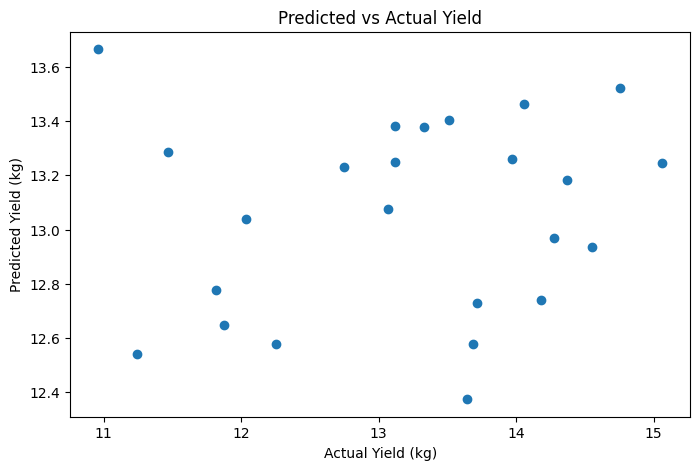

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, tuned_pred)

plt.xlabel("Actual Yield (kg)")
plt.ylabel("Predicted Yield (kg)")
plt.title("Predicted vs Actual Yield")

plt.savefig(
    "../reports/pred_vs_actual.png",
    bbox_inches="tight"
)

plt.show()

In [24]:
import os

print(os.path.exists("../models/champion.joblib"))

True
